# Toy Model: Analysis

In [12]:
sup_method='snow' # options: 'simple', 'moekratter', '50', 'snow  '

from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import pickle
from scipy import stats
import scipy


# my preferred settings
mpl.rc('lines',linewidth = 1.5)
mpl.rc('font',size = 14)
mpl.rc('axes',labelsize = 16, linewidth=1.25)
mpl.rc('xtick',labelsize = 16)
mpl.rc('ytick',labelsize = 16)
# enable math fonts
mpl.rc('mathtext', default = 'regular')
plt.rcParams['savefig.dpi'] = 400 

import seaborn as sns 

from sbin.SuppressionSimulator import SuppressionSimulator
from sbin.simulation_helper import run_trials
from sbin.plotting_utilities import plot_hist_confidence, plot_ecdf_confidence, ecdf_grid
from sbin.complexity import create_complexity_df


if sup_method=='simple':
    from sbin.suppression_utilities import suppression_factor_simple as my_suppression_factor
elif sup_method=='moekratter':
    from sbin.suppression_utilities import suppression_factor_mk21 as my_suppression_factor
elif sup_method=='50':
    from sbin.suppression_utilities import suppression_factor_50 as my_suppression_factor  
elif sup_method=='snow':
    from sbin.suppression_utilities import suppression_factor_snow as my_suppression_factor
else:
    raise



### Read in data saved from Filtering

In [13]:
with open("filtered_data.pkl", "rb") as f:
     data = pickle.load(f)
          
# conjoined list of binaries
binaries = data["binaries_filtered"]
#binaries = binaries[(binaries['Teff1']>5000) & (binaries['Teff1']<7000)].copy()

# separation values (one per KOI) for each binary
binary_separations = binaries.groupby('KOI')['SepAU'].first().values

# all KOIs that are presumed single
singles = data["kois_filtered_cc"]
#singles = singles[ (singles['teff']<4000) & (singles['teff']<7000)]


# Toy Model

### Suppress the KOIs

In [14]:

# ------------------------------------------------------------------
#  Initialise the simulator
# ------------------------------------------------------------------
KeplerSimulator = SuppressionSimulator(
    planets_cat=singles,
    sup_function=my_suppression_factor,
    join_col="KOI",
    prad_col="koi_prad",
    teff_col="koi_steff",
    random_state=42,             
)

# ------------------------------------------------------------------
#  Run it
# ------------------------------------------------------------------
res_systems, res_planets  = run_trials(
    simulator=KeplerSimulator,
    n_trials=500,
    max_a_draw=300.)

## Semi-major axis plots

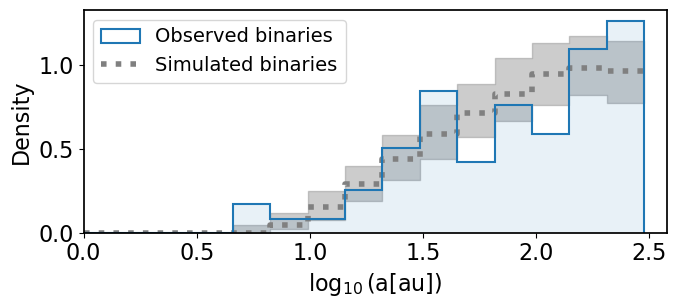

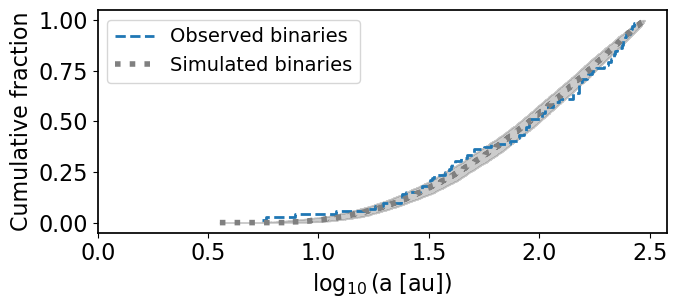

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)
log_min, log_max = 0., np.log10(300)              
n_bins = 15                             
bins   = np.linspace(log_min, log_max, n_bins + 1)   # bin edges

plot_hist_confidence(ax, 
                    res_systems.survived_semimajor, 
                    bins=bins,
                    log_flag=True,
                    label='Simulated binaries')
ax.set_xlabel(r'$\log_{10}(a [au])$')
ax.set_ylabel('Density')

# planets vs systems doesn't matter

plt.hist(np.log10(binary_separations), ls='-',
         density=True, bins=bins, histtype='step',
         color='C0', alpha=1, lw=1.5, label='Observed binaries')
plt.hist(np.log10(binary_separations), ls='--',
         density=True, bins=bins, histtype='stepfilled',
         color='C0', alpha=0.1)

handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.gca().legend(handles[::-1], labels[::-1], loc='upper left')
plt.xlim(log_min, log_max+0.1)
plt.tight_layout()
plt.savefig('plots/loga_'+sup_method+'.png')


fig, ax = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)
   
log_obs = np.log10(binary_separations)   # work in log10 just like the sims
xs_obs, ys_obs = ecdf_grid(log_obs[log_obs<log_max])
plt.step(xs_obs, ys_obs, where='post',
        color='C0', lw=2, linestyle='--', label='Observed binaries')


plot_ecdf_confidence(ax, 
                     res_systems.survived_semimajor, 
                     log_flag=True, label='Simulated binaries')


ax.set_xlabel(r'$\log_{10}(a\;[\mathrm{au}])$')

ax.set_ylabel('Cumulative fraction')
plt.legend()
plt.xlim(log_min, log_max+0.1)
plt.tight_layout()

plt.savefig('plots/loga_cdf_'+sup_method+'.png')


In [ ]:

def calculate_semimajor_stats(
    a_obs,
    a_sim_trials,
    a_max=100,
    seed=42,
):
    """
    Parameters
    ----------
    a_obs : 1‑D array (AU) – observed semi‑major axes.
    a_sim_trials : 2‑D array (n_trials, n_per_trial) – simulated axes.
    seed : int – reproducibility.
    """
    rng = np.random.default_rng(seed)
    
    log_obs   = np.log10(a_obs[a_obs<a_max])

    # -------------------------------------------------
    # 6.2  Distance metrics for each trial
    # -------------------------------------------------
    ks_trials    = np.empty(len(a_sim_trials))
    ad_trials    = np.empty(len(a_sim_trials))

    for i, trial in enumerate(a_sim_trials):
        log_sim  = np.log10(trial[trial<a_max])   # shape (T, N_sim)
        ks_trials[i]    = stats.ks_2samp(log_obs, log_sim).pvalue
        ad_trials[i]    = stats.anderson_ksamp([log_obs, log_sim]).pvalue
        
    print(np.percentile(ks_trials, q=[16,50,84]))
    print(np.percentile(ad_trials, q=[16,50,84]))

    
calculate_semimajor_stats(binary_separations, res_systems.survived_semimajor)


[0.09812542 0.33561954 0.71531139]
[0.09698857 0.25       0.25      ]


/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_66332/3666801257.py:27: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  ad_trials[i]    = stats.anderson_ksamp([log_obs, log_sim]).pvalue
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_66332/3666801257.py:27: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_trials[i]    = stats.anderson_ksamp([log_obs, log_sim]).pvalue


## Multiplicity plots

Close binaries v single KOIs
0.5402717495679932
Close v wide binaries
0.6898959675406047
Planets suppressed
Simulated v bin [0.00388416 0.0152297  0.04781394]
Simualted v single KOIs [0.00012672 0.00161382 0.01294788]
Systems suppressed
Simulated v bin [0.31862941 0.57061615 0.84855775]
Simualted v single KOIs [0.27707016 0.60546517 0.86986294]


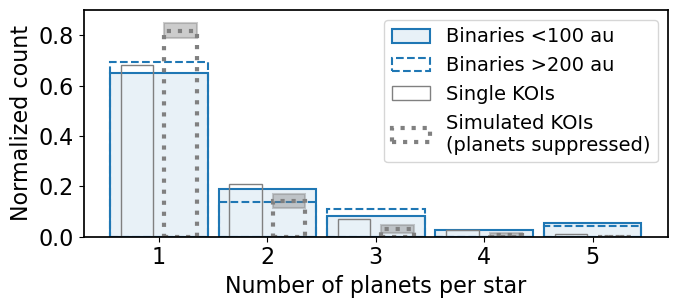

In [6]:

bin_label = 'Binaries <100 au'
bin_col = 'C0'
koi_label = 'Single KOIs'
close = binaries['SepAU']<100.
bin_planet_counts = binaries[close].groupby('KOI').size().reset_index(name='n_planets')
koi_planet_counts = singles.groupby('KOI').size().reset_index(name='n_planets')
    
print("Close binaries v single KOIs")
print(stats.mannwhitneyu(bin_planet_counts['n_planets'], koi_planet_counts['n_planets'],
                              alternative='two-sided').pvalue)

       
def multiplicity_hist(res):
    
    ntrials = len(res.survived_periods)
    sim_npl = np.zeros((ntrials,5))
    mw_trials_v_self = np.zeros(ntrials)
    mw_trials = np.zeros(ntrials)
    for i in range(ntrials):
        closest = res.survived_semimajor[i] < 100.
        vv = res.survived_periods[i][closest].groupby('KOI').size().reset_index(name='n_planets')
        nstars = len(vv)
        ww = 1./np.full(nstars, nstars, dtype=float)
        hist, _ = np.histogram(vv['n_planets'], weights=ww, 
                               bins=[0.5,1.5,2.5,3.5,4.5,5.5])
        sim_npl[i] = hist

        mw_trials[i] = stats.mannwhitneyu(bin_planet_counts['n_planets'], vv['n_planets'],
                              alternative='two-sided').pvalue
        mw_trials_v_self[i] = stats.mannwhitneyu(koi_planet_counts['n_planets'], vv['n_planets'],
                              alternative='two-sided').pvalue
    
    y = np.percentile(sim_npl, q=[16,50,84], axis=0)

    # stats test
    print("Simulated v bin", np.percentile(mw_trials,q=[16,50,84]))
    print("Simualted v single KOIs", np.percentile(mw_trials_v_self,q=[16,50,84]))

    return y


fig, ax = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)
x = np.array([1,2,3,4,5])

## the binaries

nstars = len(bin_planet_counts)
ww = 1./np.full(nstars, nstars, dtype=float)
y, _ = np.histogram(bin_planet_counts['n_planets'], 
                    weights=ww, bins=[0.5,1.5,2.5,3.5,4.5,5.5])
ax.bar(x, y, edgecolor=bin_col, facecolor='#e8f1f7', alpha=1, 
            width=0.9, linewidth=1.5,
            label=bin_label)

wide = binaries['SepAU']>200.
wide_planet_counts = binaries[wide].groupby('KOI').size().reset_index(name='n_planets')
nstars = len(wide_planet_counts)
ww = 1./np.full(nstars, nstars, dtype=float)
y, _ = np.histogram(wide_planet_counts['n_planets'], 
                    weights=ww, bins=[0.5,1.5,2.5,3.5,4.5,5.5])
ax.bar(x, y, edgecolor=bin_col, facecolor='None', alpha=1, 
            width=0.9, linewidth=1.5, ls='--',
            label='Binaries >200 au')

print("Close v wide binaries")
print(stats.mannwhitneyu(bin_planet_counts['n_planets'], wide_planet_counts['n_planets'],
                              alternative='two-sided').pvalue)

## add raw planet counts

nstars = len(koi_planet_counts)
ww = 1./np.full(nstars, nstars, dtype=float)
y, _ = np.histogram(koi_planet_counts['n_planets'], 
                    weights=ww, bins=[0.5,1.5,2.5,3.5,4.5,5.5])
ax.bar(x-0.2, y, ls='-', edgecolor='gray', facecolor='None',  
            width=0.3, lw=1, label=koi_label)


## suppressed planet counts

print("Planets suppressed")
y = multiplicity_hist(res_planets)

ax.bar(x+0.2, y[1], ls=':', edgecolor='gray', facecolor='none',  
            width=0.3, lw=3,
            label='Simulated KOIs \n(planets suppressed)')

ax.bar(x + 0.2,
       height = y[2] - y[0],
       bottom = y[0],
       width = 0.3,
       edgecolor = 'gray',
       facecolor = 'gray',
       linewidth = 1.5,
       alpha = 0.4)

print("Systems suppressed")
y = multiplicity_hist(res_systems)
# this looks like the single KOIs, naturally

plt.xlabel('Number of planets per star')
plt.ylabel('Normalized count')
plt.legend()
plt.ylim(0,0.9)
plt.tight_layout()

plt.savefig(f'plots/multiplicity_{sup_method}.png')



## Planet radii

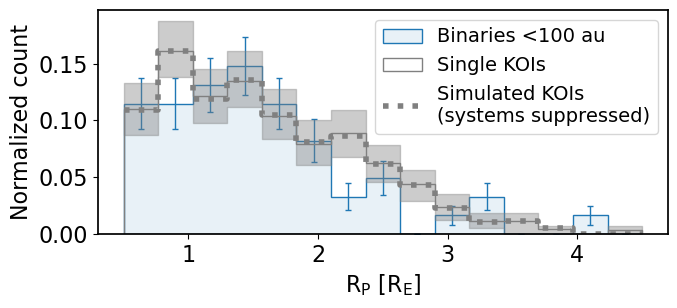

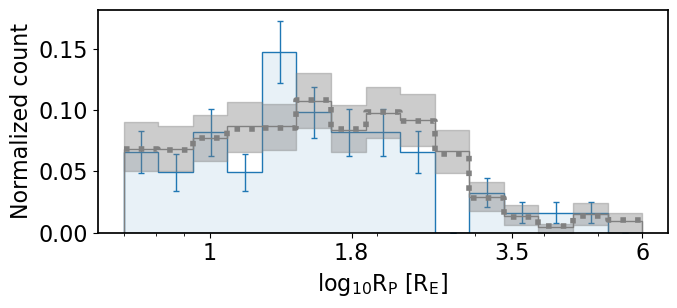

In [ ]:
nbins=15

for option in ['linear','log']:
    
    if option=='linear':
        lin_histrange=[0.5,4.5]
        bins = np.linspace(lin_histrange[0], lin_histrange[1], nbins + 1)
    else:
        log_histrange=[np.log10(0.7),np.log10(6)]
        bins = np.logspace(log_histrange[0], log_histrange[1], nbins + 1)

    fig, ax = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)


    # plot the binaries
    close = binaries['SepAU']<100.
    nplanets = len(binaries[close])
    ww = 1./np.full(nplanets, nplanets, dtype=float)
    y, _, _ = plt.hist(binaries['Rppri'][close], zorder=0,
                bins=bins, weights=ww, lw=1.5,
                histtype='stepfilled', 
                edgecolor='#1f77b4', facecolor='#e8f1f7',
                label='Binaries <100 au')
    x = bins[:-1]+np.diff(bins)/2.
    plt.errorbar(x, y, np.sqrt(y)/len(y), zorder=0,
                 ls='None', lw=1, capsize=2, c='C0')    


    nplanets = len(singles)
    ww = 1./np.full(nplanets, nplanets, dtype=float)
    y, _, _ = plt.hist(singles['koi_prad'], histtype='step',
                    ls='-', edgecolor='gray', lw=1,
                    weights=ww, bins=bins,
                    label='Single KOIs')
    
    # plot the KOIs
    samples = [None]*len(res_systems.survived_radii)
    for i, trial in enumerate(res_systems.survived_radii):
        closest = res_systems.survived_semimajor[i] < 100.
        samples[i] = trial[closest].values
    plot_hist_confidence(ax, 
                samples, 
                bins=bins,
                log_flag=False,
                density_flag=False,
                weights_flag=True, 
                label='Simulated KOIs\n(systems suppressed)')
    
    
    
    if option=='linear':
        handles, labels = plt.gca().get_legend_handles_labels()
        legend = plt.legend([handles[0], handles[1], handles[2]], [labels[0], labels[1], labels[2]], loc='upper right')
        plt.xlabel('$R_P$ [$R_E$]')        
    else:
        plt.xlabel('$log_{10} R_P$ [$R_E$]')  
        plt.xscale('log')

        custom_log_ticks = [1, 1.8, 3.5, 6]
        plt.gca().set_xticks(custom_log_ticks)
        plt.gca().set_xticklabels([str(t) for t in custom_log_ticks])

    plt.ylabel('Normalized count')
    plt.tight_layout()

## Complexity

Close vs KOI KS statistic: 0.4078
p-value: 0.2638
MW 0.3560889087129771
Wide vs KOI KS statistic: nan
p-value: nan
MW nan


/Users/f003p9d/Research/importance_of_binarity/sbin/complexity.py:78: RuntimeWarning: divide by zero encountered in log
  entropy = np.sum(p_star * np.log(p_star))
/Users/f003p9d/Research/importance_of_binarity/sbin/complexity.py:78: RuntimeWarning: invalid value encountered in multiply
  entropy = np.sum(p_star * np.log(p_star))


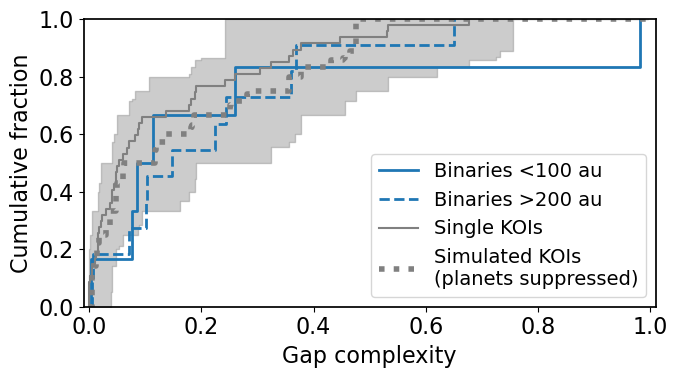

In [10]:

# this ends up a sample size of 1 lol
#cool = (binaries['SepAU']<100.) & (binaries['Teff1']<4500.)
#cool_df = create_complexity_df(binaries[cool])

koi_df = create_complexity_df(singles)
col = 'C0'
    
bin_df = create_complexity_df(binaries[binaries['SepAU']<100.])
koi_complexity = koi_df[koi_df['n_planets']>2]['gap_complexity'].values

fig, ax = plt.subplots(figsize=(7, 4))

closeb_complexity = bin_df[bin_df['n_planets']>2]['gap_complexity'].values
sns.ecdfplot(closeb_complexity, ax=ax,
             label='Binaries <100 au', linewidth=2, color=col)
ks_statistic, p_value = stats.ks_2samp(closeb_complexity, koi_complexity)
print(f"Close vs KOI KS statistic: {ks_statistic:.4f}")
print(f"p-value: {p_value:.4f}")
print("MW", stats.mannwhitneyu(closeb_complexity, koi_complexity,
                              alternative='two-sided').pvalue)


bin_df = create_complexity_df(binaries[ (binaries['SepAU']>=200.)])
closeb_complexity = bin_df[bin_df['n_planets']>2]['gap_complexity'].values
sns.ecdfplot(closeb_complexity, ax=ax, ls='--',
             linewidth=2, color=col, 
             label='Binaries >200 au')
ks_statistic, p_value = stats.ks_2samp(closeb_complexity, koi_complexity)
print(f"Wide vs KOI KS statistic: {ks_statistic:.4f}")
print(f"p-value: {p_value:.4f}")
print("MW", stats.mannwhitneyu(closeb_complexity, koi_complexity,
                              alternative='two-sided').pvalue)

sns.ecdfplot(koi_complexity, ax=ax,
             label='Single KOIs', color='gray')

plt.xlabel('Cumulative Fraction')
plt.ylabel('Complexity')

samples = [None]*len(res_planets.survived_periods)
for i, trial in enumerate(res_planets.survived_periods):
    closest = res_planets.survived_semimajor[i] < 100.
    df = create_complexity_df(trial[closest])
    samples[i] = df[df['n_planets']>2]['gap_complexity'].values
plot_ecdf_confidence(ax, samples, label='Simulated KOIs \n(planets suppressed)')
# res_systems looks identical to single KOIs

plt.legend()
plt.xlim(-0.01,1.01)
plt.ylim(0,1)
plt.xlabel('Gap complexity')
plt.ylabel('Cumulative fraction')
                     
# and the appropriate stats

plt.tight_layout()
plt.savefig(f'plots/complexity_{sup_method}.png')